<a href="https://colab.research.google.com/github/rauf358/Face-Cropper-with-Fine-Tuned-YOLOv8-on-Face-Dataset-/blob/main/Fine_Tuning_yolo8n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("canomercik/wider-face-dataset-for-yolov12-format")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/wider-face-dataset-for-yolov12-format


In [ ]:
path

'/kaggle/input/wider-face-dataset-for-yolov12-format'

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv11n model
model = YOLO("yolov8n.pt") # Ultralytics will automatically download this if not present

# This is the path to your MODIFIED DATASET's data.yaml file.
# It should point to the data.yaml you just updated.

# Train the model
train_results = model.train(
    data="/kaggle/input/wider-face-dataset-for-yolov12-format/data.yaml", # Use the path to the MODIFIED data.yaml
    epochs=2,                                # Number of training epochs
    device="cuda",                           # VERY IMPORTANT: Use 'cuda' to leverage GPU in Colab
    batch=16,                                # Specify a batch size appropriate for your GPU memory
    name="yolov8n_widerface_train"           # Give your training run a meaningful name
)

# Evaluate the model's performance on the validation set
metrics = model.val()

Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/wider-face-dataset-for-yolov12-format/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_widerface_train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

100%|██████████| 755k/755k [00:00<00:00, 99.7MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

Model summary: 129 layers, 3,011,043 parameters, 3,011,027 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 274MB/s]


...

val: Scanning /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12/val/labels... 3226 images, 0 backgrounds, 1 corrupt: 100%|██████████| 3226/3226 [00:08<00:00, 390.64it/s]

val: /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12/val/images/21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
val: /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12/val/images/39_Ice_Skating_iceskiing_39_583.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [      1.002]


WARNING ⚠️ val: Cache directory /kaggle/input/wider-face-dataset-for-yolov12-format/WIDER Face Dataset For YOLOv12/WIDER Face Dataset For YOLOv12/val is not writeable, cache not saved.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 202/202 [00:38<00:00,  5.26it/s]


                   all       3225      39675      0.772      0.474      0.549      0.281
Speed: 0.3ms preprocess, 3.3ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/detect/yolov8n_widerface_train32


In [ ]:
!nvidia-smi

Thu Jun 26 09:37:17 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             32W /   70W |    1552MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
results=model("/content/WhatsApp Image 2025-06-26 at 2.38.54 AM.jpeg")


image 1/1 /content/WhatsApp Image 2025-06-26 at 2.38.54 AM.jpeg: 288x640 14 faces, 64.9ms
Speed: 7.5ms preprocess, 64.9ms inference, 2.7ms postprocess per image at shape (1, 3, 288, 640)


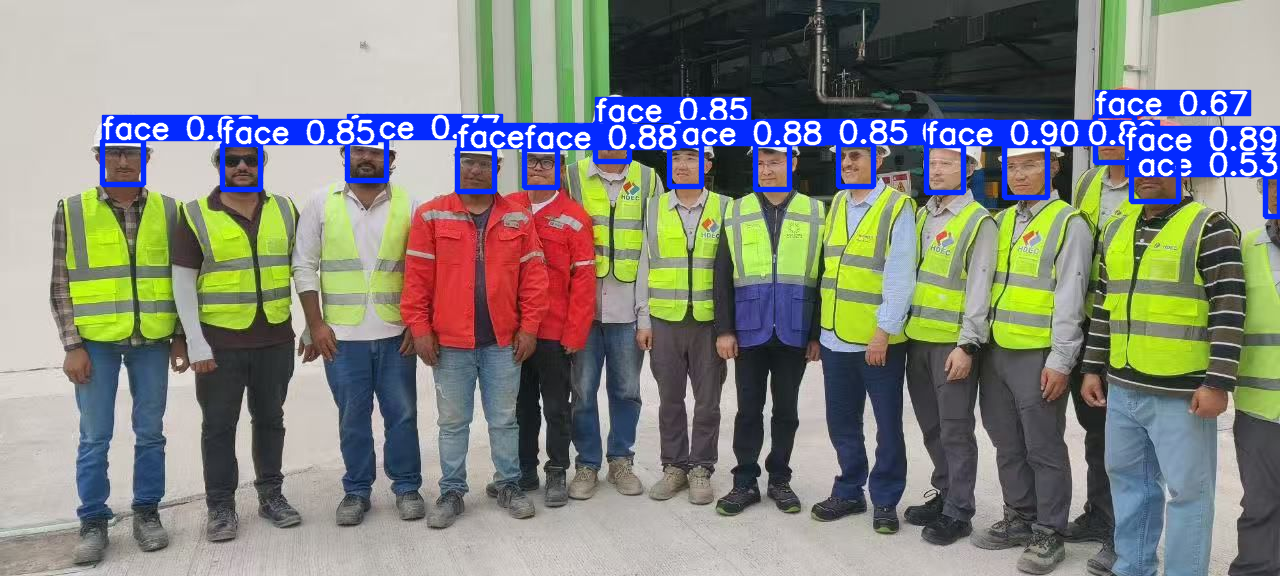

In [ ]:
for result in results:
    result.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')b

Mounted at /content/drive


In [ ]:
import os
import shutil

# Replace 'yolov8n_widerface_train' with the actual name of your training run
source_model_path_in_colab = "/content/runs/detect/yolov8n_widerface_train3/weights/best.pt"

# Define a folder in your Google Drive to save the model
drive_save_dir = '/content/drive/MyDrive/my_yolov8_trained_models'
os.makedirs(drive_save_dir, exist_ok=True) # Create the folder if it doesn't exist

# Define the full path for the saved model in Drive
destination_model_path_in_drive = os.path.join(drive_save_dir, 'my_face_detector_yolov8n_best.pt')

# Copy the file
try:
    shutil.copy(source_model_path_in_colab, destination_model_path_in_drive)
    print(f"Model successfully saved to Google Drive: {destination_model_path_in_drive}")
except FileNotFoundError:
    print(f"Error: Source model file not found at {source_model_path_in_colab}. "
          "Please double-check your training run name and path.")
except Exception as e:
    print(f"An error occurred while saving to Google Drive: {e}")

Model successfully saved to Google Drive: /content/drive/MyDrive/my_yolov8_trained_models/my_face_detector_yolov8n_best.pt
